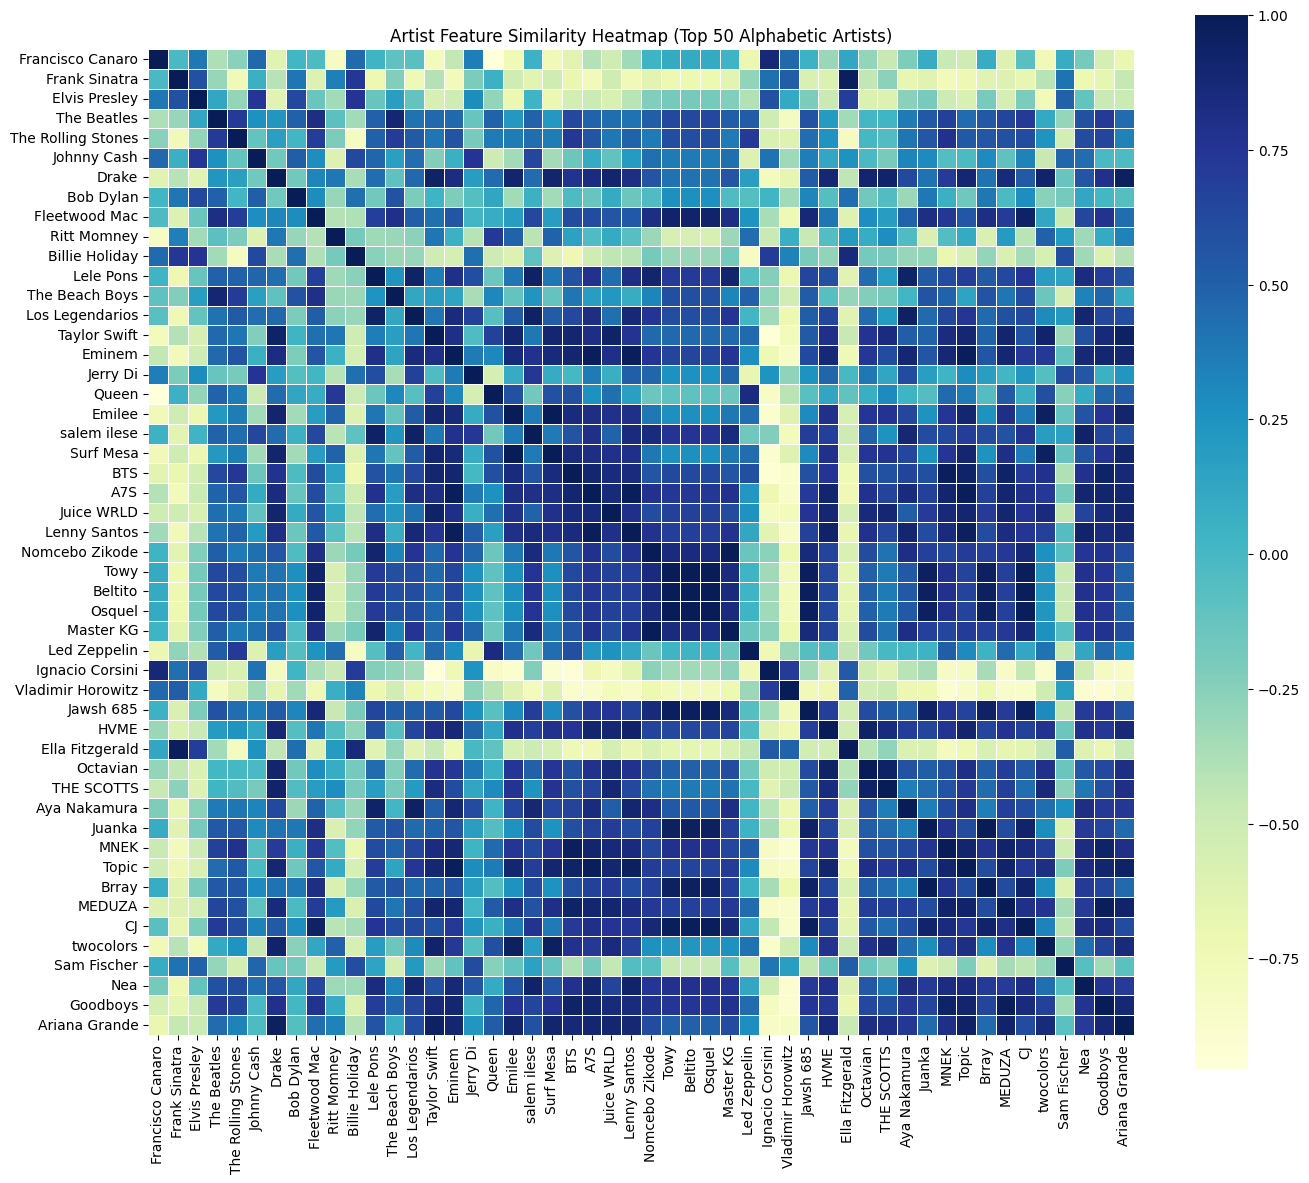

Graph has 50 nodes and 658 edges.


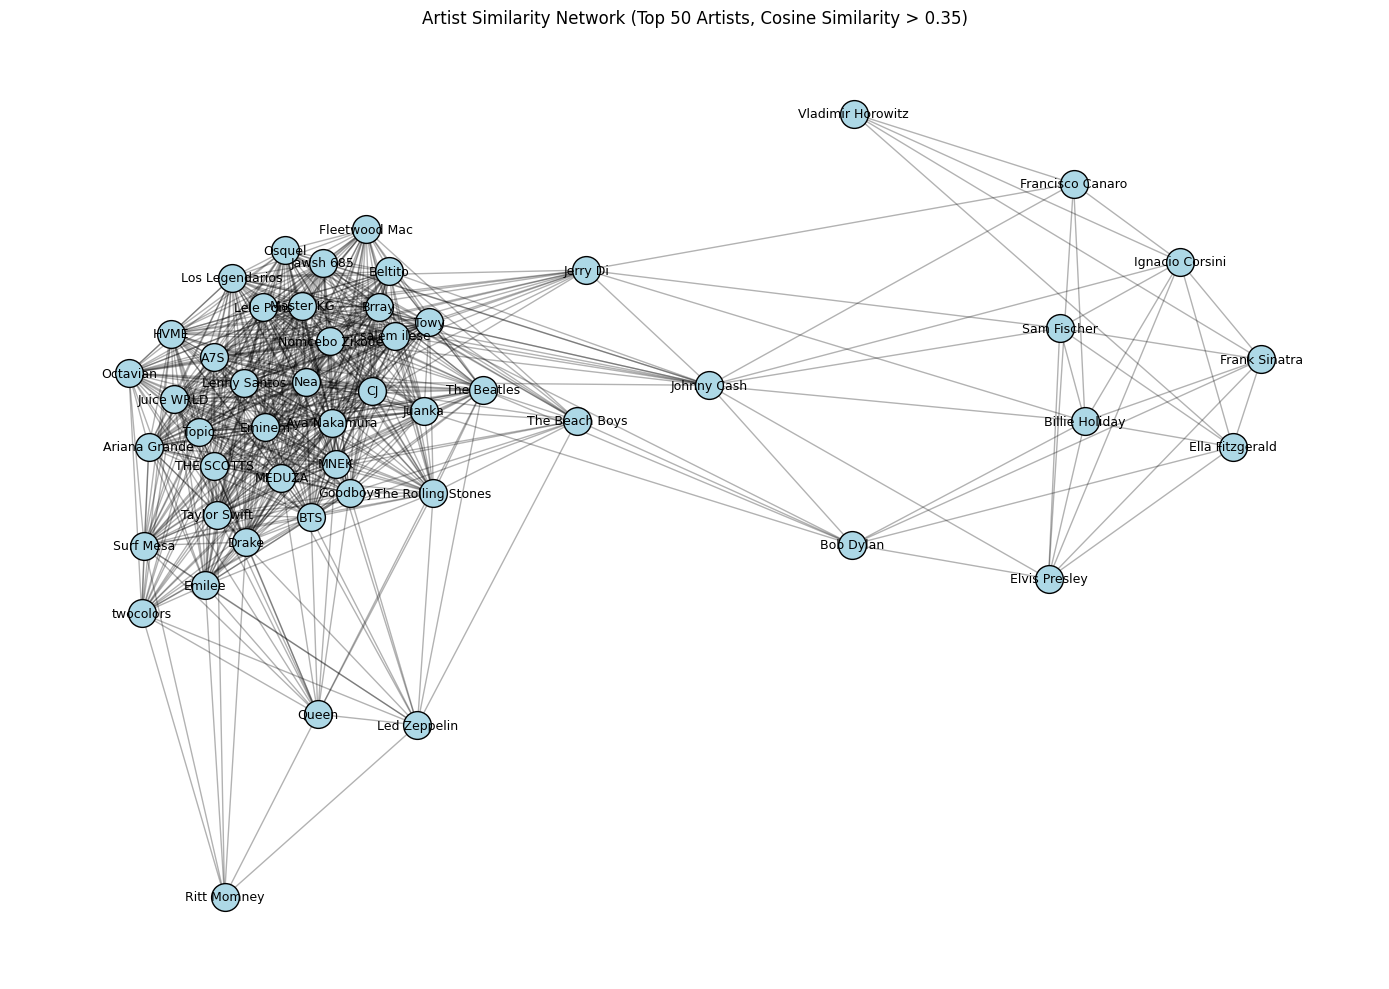

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import re

artist_df = pd.read_csv('/content/data_by_artist.csv')

artist_df = artist_df[artist_df['artists'].apply(lambda name: bool(re.fullmatch(r'[0-9A-Za-z ]+', name)))]
artist_df.reset_index(drop=True, inplace=True)

features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'tempo']
X = artist_df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cos_sim_matrix = cosine_similarity(X_scaled)
artist_names = artist_df['artists'].values
similarity_df = pd.DataFrame(cos_sim_matrix, index=artist_names, columns=artist_names)

artist_df['norm_count'] = (artist_df['count'] - artist_df['count'].min()) / (artist_df['count'].max() - artist_df['count'].min())
artist_df['norm_popularity'] = (artist_df['popularity'] - artist_df['popularity'].min()) / (artist_df['popularity'].max() - artist_df['popularity'].min())
artist_df['weighted_score'] = 0.7 * artist_df['norm_count'] + 0.3 * artist_df['norm_popularity']

top_artists = artist_df.sort_values(by='weighted_score', ascending=False).head(50)['artists'].values
top_similarity_df = similarity_df.loc[top_artists, top_artists]

plt.figure(figsize=(14, 12))
sns.heatmap(top_similarity_df, cmap='YlGnBu', square=True, linewidths=0.5)
plt.title("Artist Feature Similarity Heatmap (Top 50 Alphabetic Artists)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

threshold = 0.35
G = nx.Graph()

for artist in top_similarity_df.index:
    G.add_node(artist)

for i in top_similarity_df.index:
    for j in top_similarity_df.columns:
        if i != j and top_similarity_df.loc[i, j] > threshold:
            G.add_edge(i, j, weight=top_similarity_df.loc[i, j])

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

pos = nx.spring_layout(G, k=0.45, seed=42)
plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Artist Similarity Network (Top 50 Artists, Cosine Similarity > 0.35)")
plt.axis('off')
plt.tight_layout()
plt.show()
